In [1]:
import quante as qt

In [2]:
import quante as qt

a, b = 1, [1, 2, 3]
show(a, b)

a: 1; b: [1, 2, 3]


## 保存日志

通过在项目最开始运行：

In [12]:
qt.basicfun.set_logging(savelog=False, logtime=True)

可以将所有 `qt.basicfun.println`/`show` 的输出保存到 log 文件中，同时记录时间。

报错信息同样会记录到 log 文件中

In [13]:
show("hello world")

2025-04-05 13:34:38,539: hello world


In [14]:
qt.basicfun.set_logging(savelog=False, logtime=False)
show("hello world")

hello world


In [15]:
a = [1,2,3]
b = [4,5,6]
show(a, b)

a: [1, 2, 3]; b: [4, 5, 6]


In [ ]:
a = [1,2,3]
b = 1
show(
    a,
    b
)

a: [1, 2, 3]; b: 1


In [18]:
a, b = [1,2,3], 1
show()

a: [1, 2, 3]; b: 1


In [10]:
qt.basicfun.set_show(arg_name=False)
a = [1,2,3]
b = 1
show(
    a,
    b,
)

[1, 2, 3]
1


## 数据保存

In [ ]:
import numpy as np
a = np.random.randn(10,10)
qt.basicfun.isave("data.h5")

In [ ]:
a, = qt.basicfun.iload("data.h5")  # 这样可以得到储存的数据

也支持多个数据的的保存和导入

In [ ]:
a = [1,2,3]
b = np.random.randn(10,10)

# c, d 不能被 hdf5 直接保存，将会被序列化，失去可视化的效果
c = [a, b]
class D:
    def __init__(self, x):
        self.x = x
d = D(10)

qt.basicfun.isave("data.h5", a, b, c, d)  

In [ ]:
a, b, c, d = qt.basicfun.iload("data.h5")

如果涉及到 group，可以：

In [ ]:
a = np.random.randn(10,10)
qt.basicfun.save_hdf5("data.h5", "/", {"a": a})

('data.h5', '/')

In [ ]:
a = qt.basicfun.load_hdf5('data.h5', '/', 'a')

这种写法下，如果需要 load 更多元素，可以：

In [ ]:
a = qt.basicfun.load_hdf5('data.h5', '/', '/')

## 画图预设

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [ ]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [ ]:
qt.basicfun.print_memory_usage(a)

7.63 MB


matplotlib 默认的画图风格为：

Text(0, 0.5, '$\\sin x$')

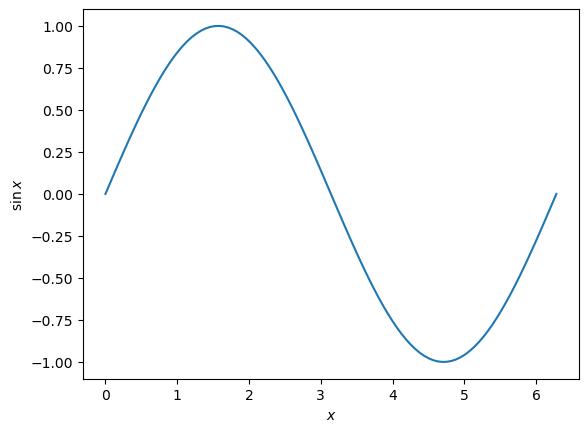

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

通过 `plt_style_use` 可以改变风格：

Text(0, 0.5, '$\\sin x$')

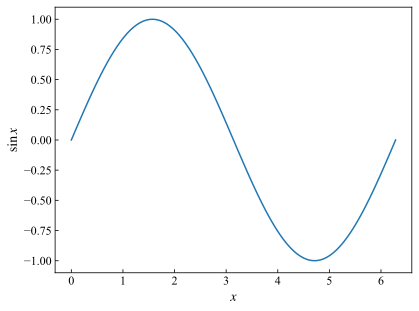

In [16]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use()

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

Text(0, 0.5, '$\\sin x$')

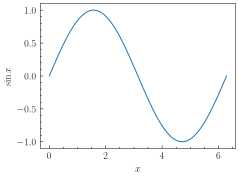

In [19]:
import matplotlib.pyplot as plt
import numpy as np
qt.basicfun.plt_style_use('science')

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$\sin x$')

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [ ]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [ ]:
qt.basicfun.print_memory_usage(a)

7.63 MB


## 代码调试工具

### 显示代码运行运行的时间

In [ ]:
import numpy as np

def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

with Timer(myfun, singlestep):
    myfun(100)

Timer unit: 0.001 s

Total time: 0.0123768 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_32800\2100961480.py
Function: singlestep at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def singlestep(a, i, j):
     4     10000          9.1      0.0     73.2      a = np.sin(a)
     5     10000          3.3      0.0     26.8      return a + i + j

Total time: 0.0288895 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_32800\2100961480.py
Function: myfun at line 7

Line #      Hits         Time  Per Hit   % Time  Line Contents
     7                                           def myfun(dim):
     8         1          0.1      0.1      0.5      mat = np.random.randn(dim,dim)
     9       101          0.0      0.0      0.1      for i in range(dim):
    10     10100          2.3      0.0      8.1          for j in range(dim):
    11     10000         26.4      0.0     91.4              mat[i,j] = singlestep(mat[i,j], i,

显示了每一行运行需要的时间

如果是 py 文件中，可以使用 profile 装饰器

```python
@bf.profile()
def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

@bf.profile()
def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

myfun(100)
```